In [5]:
# --------------------------------------------------
# Imports
# --------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

plt.style.use("seaborn-v0_8")

In [10]:
# --------------------------------------------------
# Load Dataset
# --------------------------------------------------

filename = "stock_data_july_2025.csv"  # Change if needed
df = pd.read_csv(filename)

# Convert date column
df["Date"] = pd.to_datetime(df["Date"])

# Inspect structure
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nUnique Companies:", df["Ticker"].nunique())

df.head()

Dataset Shape: (4346, 14)

Columns: Index(['Date', 'Ticker', 'Open Price', 'Close Price', 'High Price',
       'Low Price', 'Volume Traded', 'Market Cap', 'PE Ratio',
       'Dividend Yield', 'EPS', '52 Week High', '52 Week Low', 'Sector'],
      dtype='object')

Unique Companies: 82


,Date,Ticker,Open Price,Close Price,High Price,Low Price,Volume Traded,Market Cap,PE Ratio,Dividend Yield,EPS,52 Week High,52 Week Low,Sector
0,2025-06-01,AAPL,185.96,187.79,188.85,183.74,42257183,2.931356e+12,28.37,0.49,6.62,248.20,155.68,Technology
1,2025-06-01,ABBV,189.63,193.64,194.31,188.03,33074970,3.289227e+11,16.74,3.51,11.57,210.83,127.91,Healthcare
2,2025-06-01,ABT,118.79,120.08,120.53,118.01,17130934,2.001333e+11,19.39,1.84,6.19,140.79,99.26,Healthcare
3,2025-06-01,ADBE,584.51,567.78,587.97,561.25,11080360,2.460380e+11,43.29,0.00,13.12,727.11,407.82,Technology
4,2025-06-01,ADP,253.46,255.60,258.59,249.91,10319559,1.052471e+11,29.92,2.04,8.54,303.75,234.28,Financials


In [12]:
# --------------------------------------------------
# Data Cleaning and Preparation
# --------------------------------------------------

# Select companies (change if needed)
companies = ["AAL", "AAPL", "MSFT", "XOM"]

df = df[df["Ticker"].isin(companies)]

# Sort properly
df = df.sort_values(["Ticker", "Date"])

# Calculate daily returns
df["Return"] = df.groupby("Ticker")["Close Price"].pct_change()

# Remove missing values
df = df.dropna()

df.head()

,Date,Ticker,Open Price,Close Price,High Price,Low Price,Volume Traded,Market Cap,PE Ratio,Dividend Yield,EPS,52 Week High,52 Week Low,Sector,Return
82,2025-06-02,AAPL,211.57,213.07,214.91,210.10,49806398,3.325971e+12,25.98,0.51,8.20,258.68,176.02,Technology,0.134618
164,2025-06-03,AAPL,197.75,195.61,200.13,193.48,29588431,3.053424e+12,30.35,0.52,6.45,233.17,159.61,Technology,-0.081945
246,2025-06-04,AAPL,215.31,215.44,217.79,214.77,38591730,3.362966e+12,25.26,0.47,8.53,288.47,156.36,Technology,0.101375
328,2025-06-05,AAPL,218.80,226.08,228.69,216.68,73159323,3.529054e+12,30.97,0.46,7.30,284.50,157.83,Technology,0.049387
410,2025-06-06,AAPL,200.95,195.53,203.35,192.85,64831615,3.052176e+12,27.23,0.47,7.18,259.72,177.58,Technology,-0.135129


<Figure size 921.6x691.2 with 0 Axes>

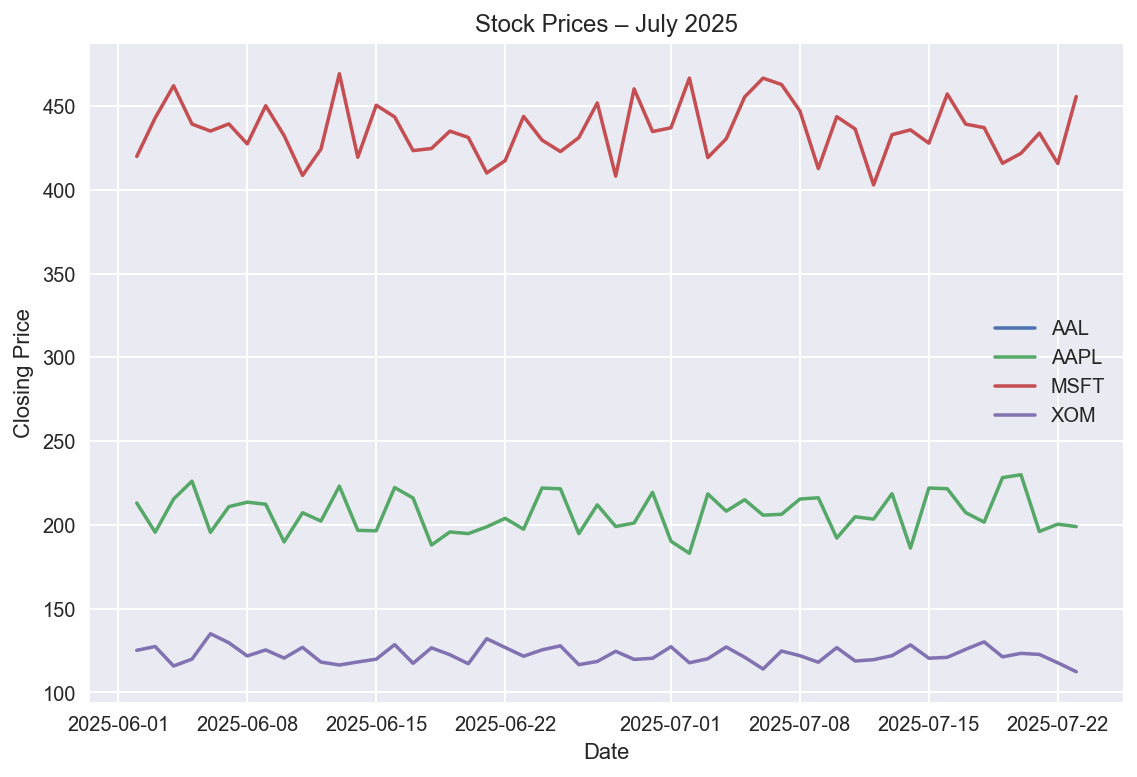

In [13]:
# --------------------------------------------------
# Relational Plot
# --------------------------------------------------

plt.figure(dpi=144)

for company in companies:
    subset = df[df["Ticker"] == company]
    plt.plot(subset["Date"], subset["Close Price"], label=company)

plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.title("Stock Prices – July 2025")
plt.legend()
plt.tight_layout()
plt.show()

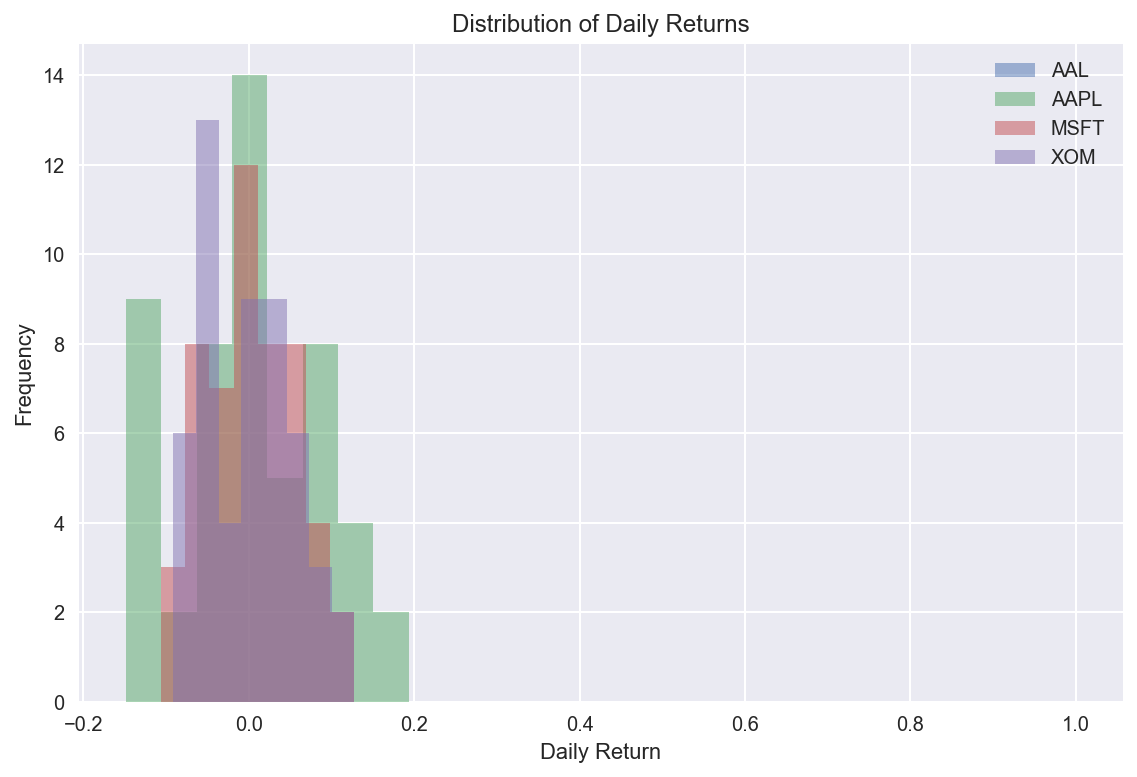

In [14]:
# --------------------------------------------------
# Categorical Plot
# --------------------------------------------------

plt.figure(dpi=144)

for company in companies:
    subset = df[df["Ticker"] == company]
    plt.hist(subset["Return"], bins=8, alpha=0.5, label=company)

plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Returns")
plt.legend()
plt.tight_layout()
plt.show()

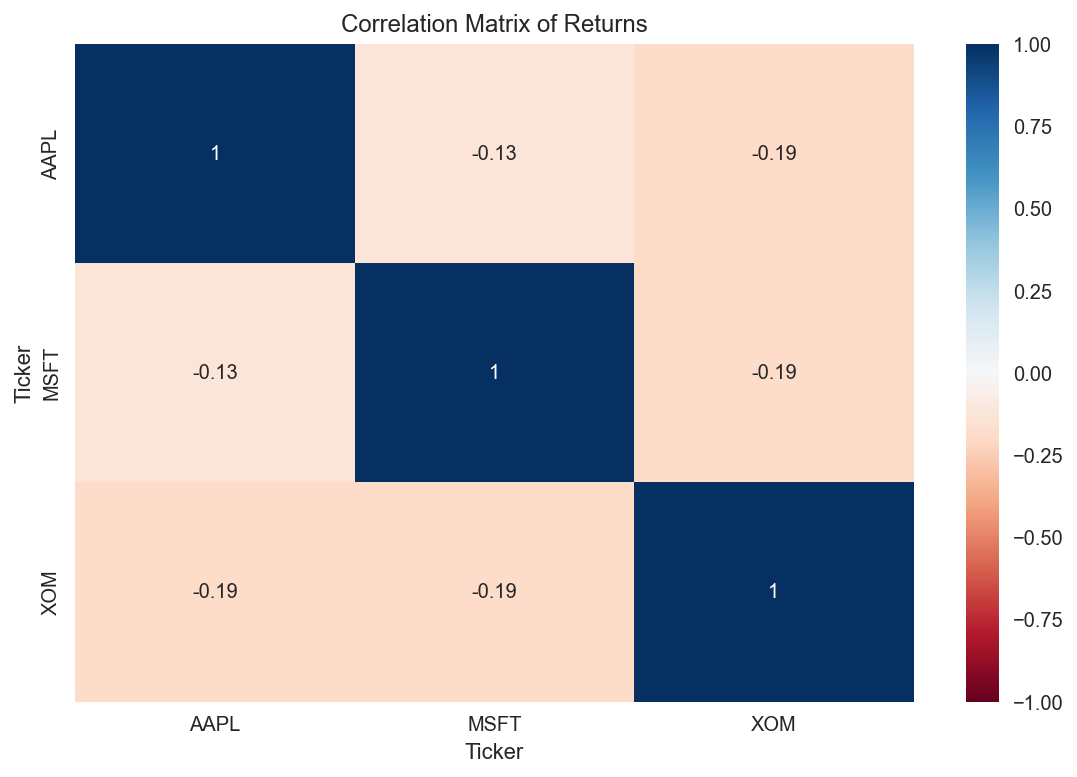

In [15]:
# --------------------------------------------------
# Statistical Plot
# --------------------------------------------------

pivot = df.pivot(index="Date",
                 columns="Ticker",
                 values="Return")

corr_matrix = pivot.corr()

plt.figure(dpi=144)
sns.heatmap(corr_matrix,
            annot=True,
            cmap="RdBu",
            vmin=-1,
            vmax=1)

plt.title("Correlation Matrix of Returns")
plt.tight_layout()
plt.show()

In [17]:
# --------------------------------------------------
# Statistical Moments
# --------------------------------------------------

print("Statistical Moments (Daily Returns)\n")

for company in companies:

    data = df[df["Ticker"] == company]["Return"]

    n = len(data)

    print(company)
    print("Number of Observations:", n)

    if n < 3:
        print("Not enough data to compute skewness and kurtosis\n")
        print("----------------------------------")
        continue

    mean = np.mean(data)
    std = np.std(data)
    skew = stats.skew(data)
    kurt = stats.kurtosis(data)

    print("Mean:      ", round(mean, 6))
    print("Std Dev:   ", round(std, 6))
    print("Skewness:  ", round(skew, 4))
    print("Kurtosis:  ", round(kurt, 4))
    print("----------------------------------")

Statistical Moments (Daily Returns)

AAL
Number of Observations: 0
Not enough data to compute skewness and kurtosis

----------------------------------
AAPL
Number of Observations: 52
Mean:       0.004796
Std Dev:    0.085945
Skewness:   0.0858
Kurtosis:   -0.5274
----------------------------------
MSFT
Number of Observations: 52
Mean:       0.002104
Std Dev:    0.054558
Skewness:   0.106
Kurtosis:   -0.5984
----------------------------------
XOM
Number of Observations: 52
Mean:       0.000237
Std Dev:    0.054744
Skewness:   0.2832
Kurtosis:   -0.6431
----------------------------------
